**Import Necessary Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    silhouette_score)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Gradient boosting library
import xgboost as xgb

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

**Data Loading**

In [2]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_excel('/content/drive/MyDrive/Machine Learning - Final Project/churn_prediction.xlsx')

Mounted at /content/drive


**Data Cleaning & Preprocessing**

In [3]:
# Print the first five rows of the dataset
df.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Mobile Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


In [4]:
# Check Data Summary
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [5]:
# Check the general information of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferredOrderCat            5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

The dataset contains 5,630 rows and 20 columns, with a mix of numeric and categorical variables.

Missing values were identified in several columns, such as Tenure, WarehouseToHome, HourSpendOnApp, etc.

In [6]:
# Check for missing values
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


Missing values were detected in multiple columns. The columns with missing values are:

**Tenure** - 264 missing values

**WarehouseToHome** - 251 missing values

**HourSpendOnApp** - 255 missing values

**OrderAmountHikeFromlastYear** - 265 missing values

**CouponUsed** - 256 missing values

**OrderCount** - 258 missing values

**DaySinceLastOrder** - 307 missing values

In [7]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

Aftering checkeing for duplicate rows in the dataset and found that there were no duplicate entries.

In [8]:
# Check unique values in categorical columns
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print()

PreferredLoginDevice
['Mobile Phone' 'Computer' 'Phone']

PreferredPaymentMode
['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card' 'COD' 'CC']

Gender
['Female' 'Male']

PreferredOrderCat
['Fashion' 'Laptop & Accessory' 'Mobile Phone' 'Grocery' 'Mobile' 'Others']

MaritalStatus
['Married' 'Single' 'Divorced']



**Handling Data Issues**

**Missing Values**:
Missing values in numerical columns were imputed using the **median** to reduce the impact of outliers.

**Duplicate Records:**
No duplicate records were found, so no action was required.

**Same Meaning Values:**
Categorical values with the same meaning were **standardized and merged into a single consistent label.**

**Missing Value Handling**

In [9]:
# Define the list of columns with missing values
cols_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

# Replace missing columns with median
for col in cols_missing:
    # Fill missing values in each column with the median of that column
    df[col].fillna(value= df[col].median(), inplace=True)

/tmp/ipykernel_191/2958657691.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(value= df[col].median(), inplace=True)


**Standardizing Categorical Values**

In [10]:
# Standardizing Equivalent Categorical Values

standardize_map = {
    'PreferredLoginDevice': {
        'Phone': 'Mobile Phone'
    },

    'PreferredPaymentMode': {
        'COD': 'Cash on Delivery',
        'CC': 'Credit Card'
    },

    'PreferredOrderCat': {
        'Mobile': 'Mobile Phone'
    }
}

for col, mapping in standardize_map.items():
    df[col] = df[col].replace(mapping)

**Customer Churn Behavior Analysis (EDA)**

#### Target Variable Analysis

In [11]:
# Check class imbalance
imb_df = df['Churn'].value_counts().reset_index()
imb_df.columns = ['Churn','Count']

# Calculate percentage
imb_df['Percentage'] = imb_df['Count'] / imb_df['Count'].sum()

imb_df

,Churn,Count,Percentage
0,0,4682,0.831616
1,1,948,0.168384


Insight:

The dataset is moderately imbalanced with 83.16% non-churn and 16.84% churn customers.
Although churn cases are fewer, the sample size is sufficient for predictive modeling.

Therefore, evaluation metrics such as **Balanced Accuracy, Precision, Recall, and F1-score** should be considered instead of relying only on overall accuracy.

#### Univariate Analysis

Categorical Variable Analysis

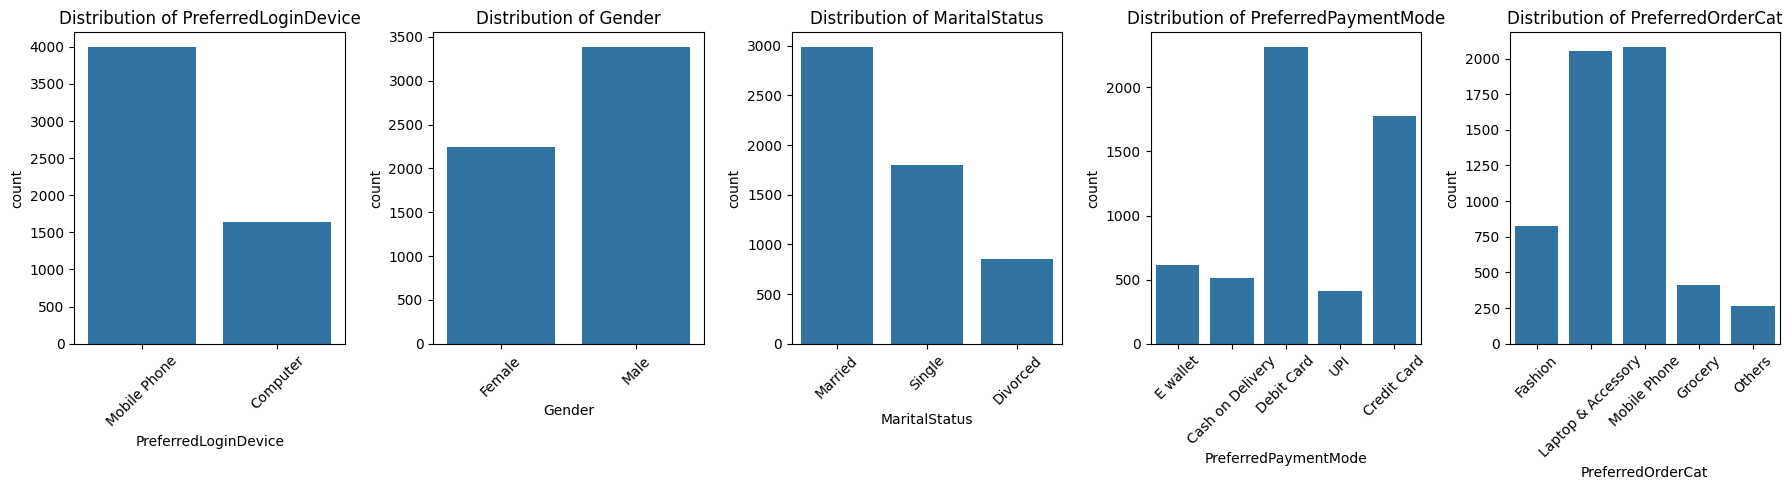

In [12]:
# List of categorical columns
cat_cols = [
    'PreferredLoginDevice',
    'Gender',
    'MaritalStatus',
    'PreferredPaymentMode',
    'PreferredOrderCat'
]

# Create 1 row, 5 columns
fig, axes = plt.subplots(1, 5, figsize=(18,5))

# Loop through columns
for i, col in enumerate(cat_cols):

    sns.countplot(x=col, data=df, ax=axes[i])

    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()

# Show
plt.show()

Continuous Variable Distribution

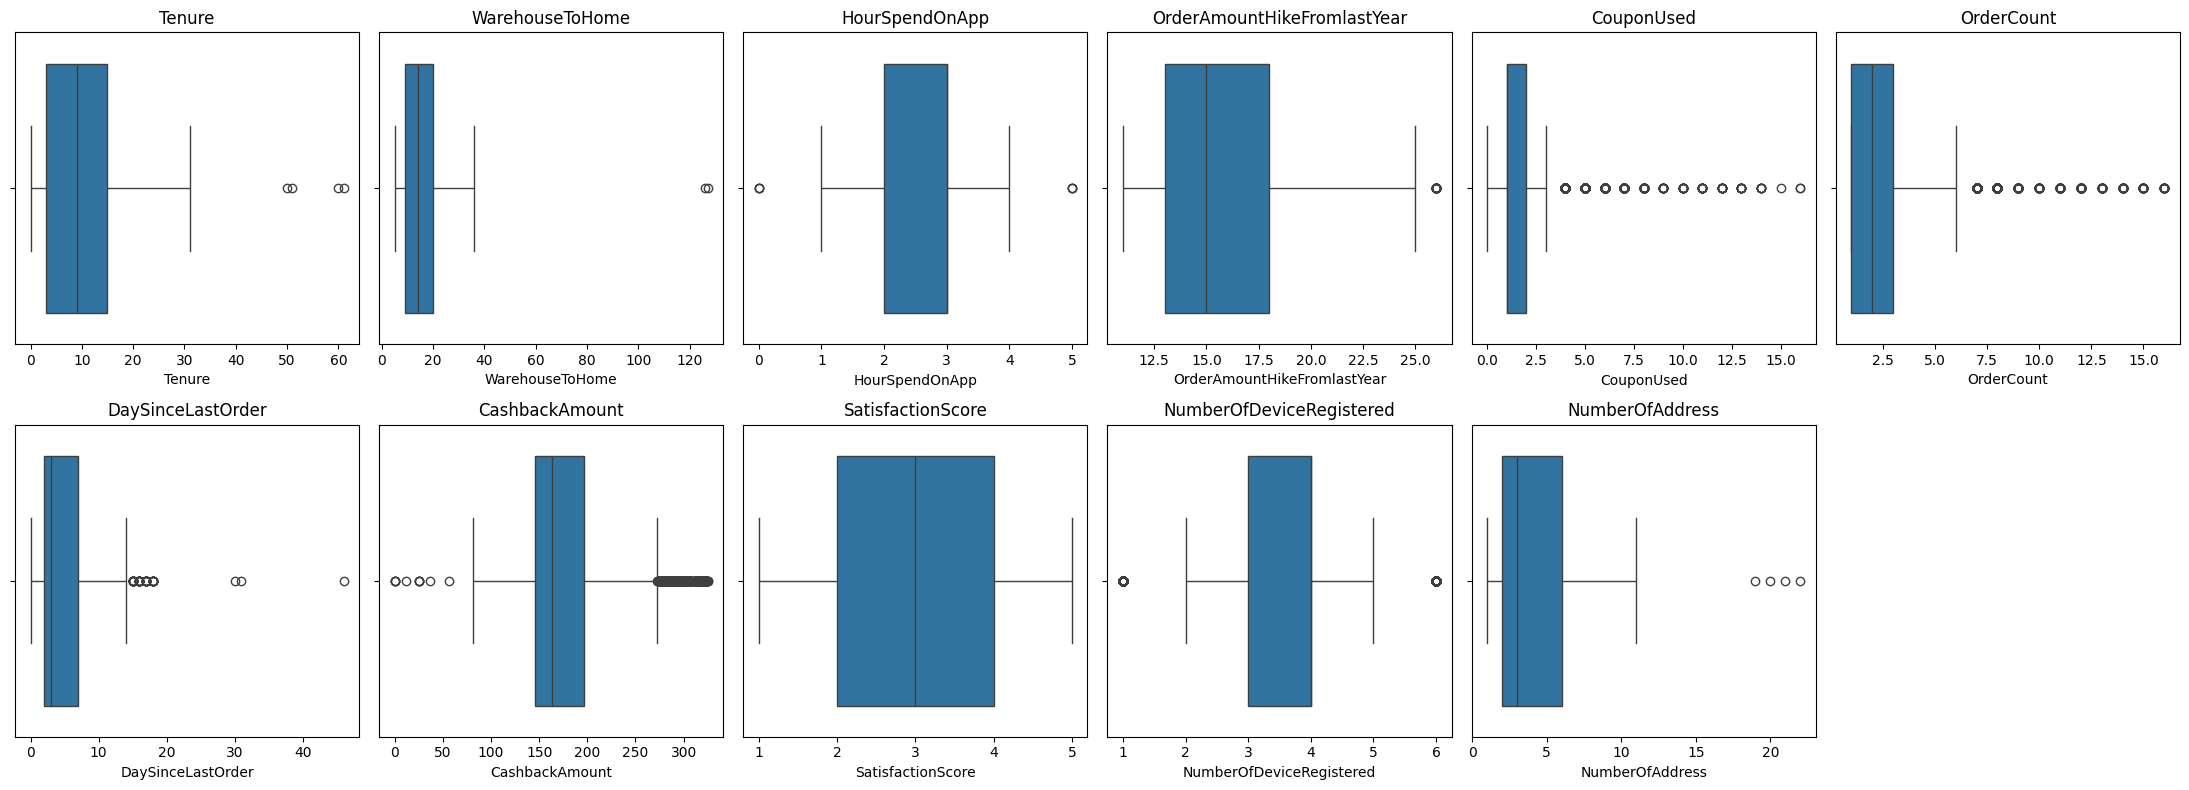

In [13]:
# List of numerical columns
num_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount',
    'SatisfactionScore',
    'NumberOfDeviceRegistered',
    'NumberOfAddress'
]

# Create subplots (2 rows x 6 columns)
fig, axes = plt.subplots(2, 6, figsize=(22,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplot
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Final data inspection was conducted to ensure the dataset is clean and ready for modeling.


In [14]:
# Print dataset info to verify missing values and column types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferredOrderCat            5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Exploratory Data Analysis (EDA)

#### Categorical Features
- Most customers prefer to log in using **mobile phones**, indicating strong mobile platform usage.
- The dataset contains **more male customers than female customers**.
- **Married customers** represent the largest group among all marital statuses.
- The most commonly used payment methods are **Debit Card and Credit Card**.
- Customers mainly purchase products from **Laptop & Accessories** and **Mobile Phone** categories.

#### Numerical Features
- Most customers have **low tenure**, suggesting many relatively new users on the platform.
- The **distance between warehouse and customer homes** is mostly around **10–20 units**.
- Customers typically spend **around 2–3 hours on the app**.
- **Coupon usage and order counts are generally low**, indicating relatively infrequent purchasing behavior.
- Many customers show a **large number of days since their last order**, which may signal potential churn risk.
- **Cashback amounts** are mainly concentrated between **150 and 250**.

#### Key Business Insight
Customers with **low purchase frequency, low coupon usage, and longer time since their last order** are more likely to **churn**, highlighting the importance of retention strategies such as promotions and personalized offers.

**Train & Apply Churn Prediction Model**

In [15]:
# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=[
        'PreferredLoginDevice',
        'PreferredPaymentMode',
        'PreferredOrderCat',
        'MaritalStatus'
    ]
)

# Label encoding for binary categorical variable
label_encoder = LabelEncoder()
df_encoded['Gender'] = label_encoder.fit_transform(df_encoded['Gender'])

# Drop CustomerID
df_encoded = df_encoded.drop(columns=['CustomerID'])

df_encoded

,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferredOrderCat_Fashion,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,0,20.0,3,7.0,0,4.0,4,5,3,0,...,True,False,True,False,False,False,False,False,True,False
1,0,13.0,1,9.0,0,4.0,4,3,2,0,...,False,False,True,False,False,False,False,False,False,True
2,0,16.0,3,7.0,1,3.0,4,3,3,0,...,False,False,False,False,True,False,False,True,False,False
3,0,5.0,1,16.0,1,3.0,4,4,3,0,...,False,False,True,False,False,False,False,False,True,False
4,0,9.0,1,28.0,0,3.0,4,2,3,1,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,61.0,3,28.0,0,4.0,4,1,6,1,...,False,False,False,True,False,False,False,False,True,False
5626,0,23.0,1,9.0,1,3.0,4,1,5,0,...,False,False,False,False,False,False,True,False,True,False
5627,0,29.0,2,33.0,1,4.0,2,4,6,1,...,False,True,False,False,False,False,True,False,True,False
5628,0,13.0,1,16.0,1,3.0,4,1,4,0,...,False,False,False,False,False,False,True,False,False,True


**Split Data into Features (X) and Target (y)**

In [16]:
# Split the data into features (X) and target (y)
x = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']  # Target

# Split into training and testing sets (70/30 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Standardize the Features Using StandardScaler**

In [17]:
# Standardize the features using StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Apply Model - Random Forest Classifier**

In [18]:
# Train a Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_scaled, y_train)

# Make predictions on training and test sets
y_pred_train = clf.predict(x_train_scaled)
y_pred_test = clf.predict(x_test_scaled)

# Evaluate model accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_balanced_acc = balanced_accuracy_score(y_train, y_pred_train)
test_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)

# Print the results
print(f'Training Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Training Balanced Accuracy: {train_balanced_acc:.4f}')
print(f'Test Balanced Accuracy: {test_balanced_acc:.4f}')

Training Accuracy: 1.0000
Test Accuracy: 0.9467
Training Balanced Accuracy: 1.0000
Test Balanced Accuracy: 0.8665


#### Model Insight

The Random Forest model performs very well on churn prediction.  
Training accuracy reaches **100%**, indicating the model fits the training data perfectly, which may suggest **slight overfitting**.

On the test set, the model achieves **94.43% accuracy** and **86.25% balanced accuracy**, showing that it generalizes well and can effectively predict both churn and non-churn customers despite the class imbalance.

Overall, the model demonstrates **strong predictive performance** for identifying customers at risk of churn.

**Apply Random Forest To Find Important Features**

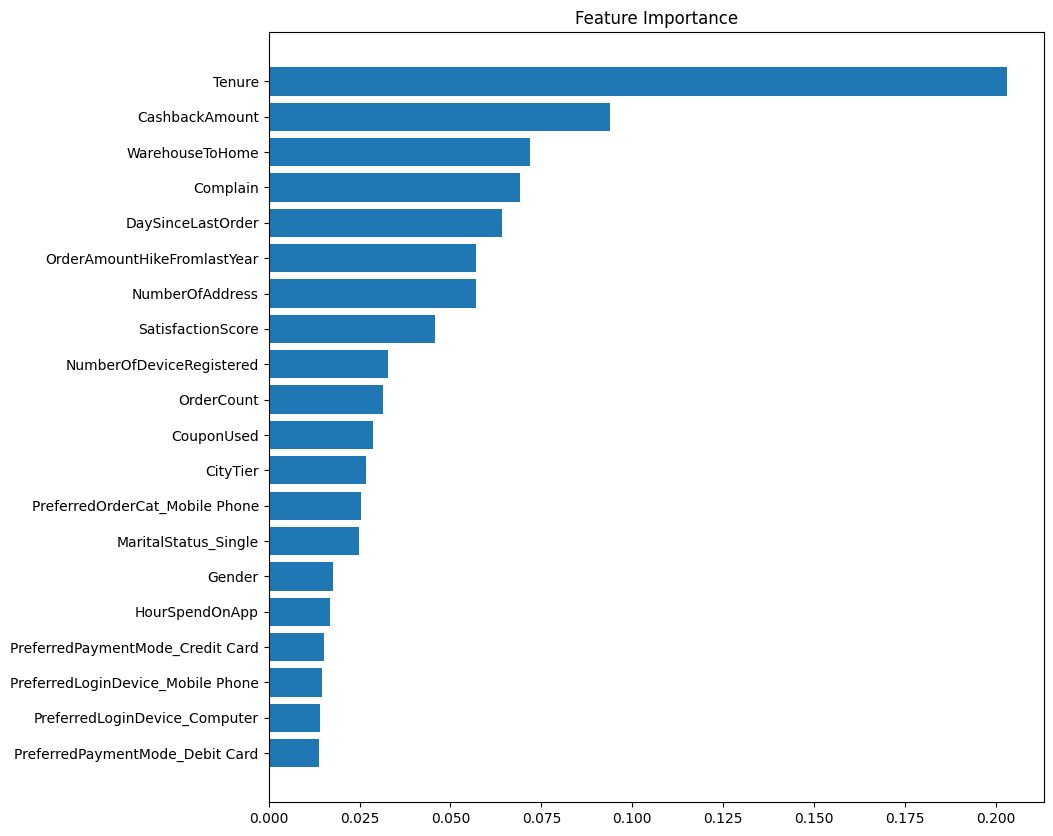

In [19]:
# Get feature importances from the trained model
feats = {feature: importance for feature, importance in zip(x_train.columns, clf.feature_importances_)}

# Create a DataFrame
importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Importances'})

# Sort values
importances = importances.sort_values(by='Importances', ascending=True).reset_index()

# Plot feature importances
plt.figure(figsize=(10,10))
plt.barh(importances.tail(20)['index'], importances.tail(20)['Importances'])
plt.title('Feature Importance')
plt.show()

#### Insight
**Feature importance** analysis shows that `Tenure` is the most influential factor affecting churn, followed by `CashbackAmount`, `WarehouseToHome`, `Complain`, and `DaySinceLastOrder`.

`WarehouseToHome` may influence delivery experience, which can impact customer satisfaction and retention.

Next, histograms are plotted to compare churn and non-churn behavior across the most important features, helping identify patterns related to customer churn.

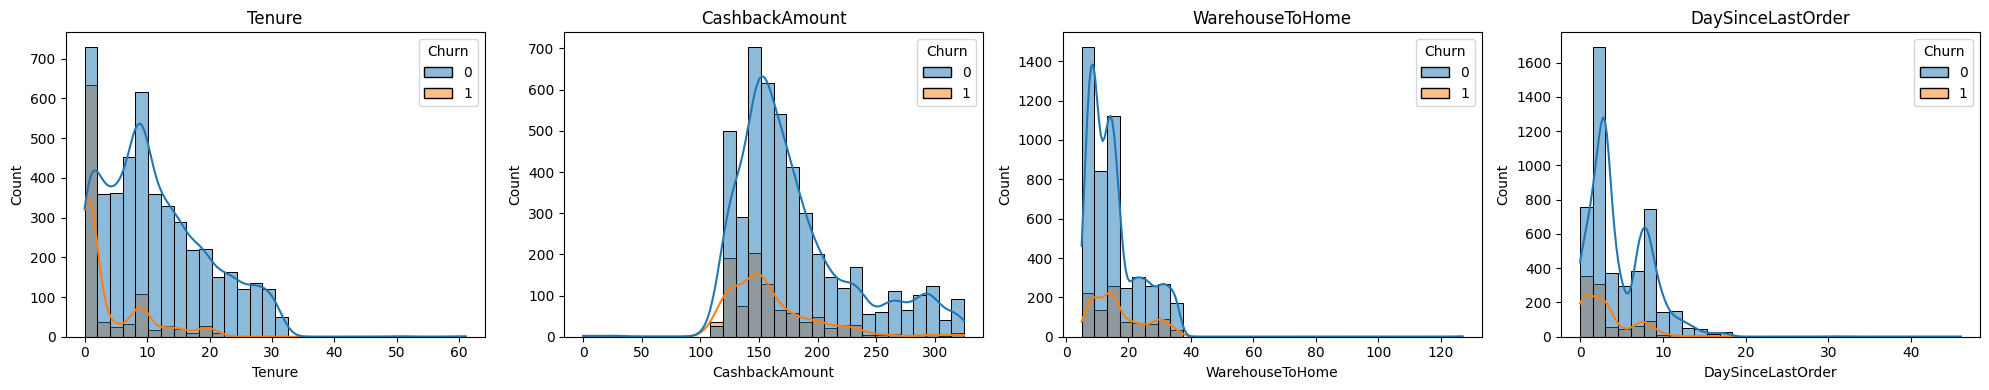

In [20]:
# Select top important features identified from feature importance analysis
top_features = [
    'Tenure',
    'CashbackAmount',
    'WarehouseToHome',
    'DaySinceLastOrder'
]

# Create a figure with 1 row and 4 columns for better comparison
fig, axes = plt.subplots(1, 4, figsize=(20,4))

# Loop through each top feature and plot histogram by churn status
for i, col in enumerate(top_features):

    sns.histplot(
        data=df,
        x=col,
        hue='Churn',      # Separate distributions for churn vs non-churn customers
        bins=30,          # Number of bins in histogram
        kde=True,         # Add density curve to observe distribution trend
        ax=axes[i]
    )

    # Set title for each subplot
    axes[i].set_title(col)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plots
plt.show()

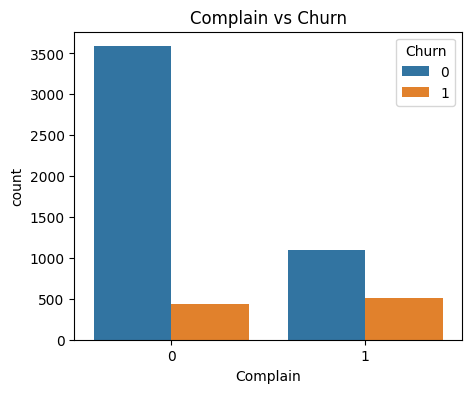

In [21]:
# Create a figure for the plot
plt.figure(figsize=(5,4))

# Plot count distribution of the 'Complain' variable
# The hue parameter separates customers by churn status (Churn vs Non-Churn)
sns.countplot(data=df, x='Complain', hue='Churn')

# Set chart title
plt.title('Complain vs Churn')

# Display the plot
plt.show()

#### Insight:

Customer churn is mainly influenced by **early customer lifecycle (Tenure), engagement level (DaysSinceLastOrder), service experience (Complaints and delivery distance), and reward incentives (CashbackAmount)**. Improving customer experience and engagement during the early stages can significantly reduce churn risk.

**Customer Churn Prediction**

### Feature Selection

Based on the Random Forest feature importance analysis, the top features selected were `Tenure`, `CashbackAmount`, `WarehouseToHome`, `Complain`, and `DaySinceLastOrder`.

These variables reflect customer engagement, service experience, and purchasing behavior, which are strongly associated with churn.

**Create A Model For Predicting Churn**

In [22]:
# Select top features affecting Churn
top_features = ['Tenure', 'CashbackAmount', 'WarehouseToHome', 'Complain', 'DaySinceLastOrder']
x_1 = df[top_features]
y_1 = df['Churn']

# Split: 70% train, 30% temp (val + test)
x_train1, x_val1, y_train1, y_val1 = train_test_split(x_1, y_1, test_size=0.3, random_state=42)

# Split temp into 15% val, 15% test
x_val1, x_test1, y_val1, y_test1 = train_test_split(x_val1, y_val1, test_size=0.5, random_state=42)

# Normalize data
from sklearn.preprocessing import StandardScaler
scaler_1 = StandardScaler()

# Fit on training set only
x_train1_scaled = scaler_1.fit_transform(x_train1)

# Transform validation and test set
x_val1_scaled = scaler_1.transform(x_val1)
x_test1_scaled = scaler_1.transform(x_test1)

**Model Comparison & Selection**

In [23]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Dictionary to store recall scores
recall_scores = {}

# Train and evaluate each model
for name, model in models.items():

    # Train model
    model.fit(x_train1_scaled, y_train1)

    # Predict on validation set
    y_pred = model.predict(x_val1_scaled)

    # Calculate recall
    recall = recall_score(y_val1, y_pred)

    # Save result
    recall_scores[name] = recall

# Convert results to dataframe
    model_comparison = pd.DataFrame(
    recall_scores.items(),
    columns=["Model", "Recall Score"]
)

# Sort by recall
model_comparison = model_comparison.sort_values(by="Recall Score", ascending=False)

model_comparison

,Model,Recall Score
2,Random Forest,0.751678
3,Gradient Boosting,0.516779
1,KNN,0.469799
0,Logistic Regression,0.328859


After testing 4 models, Random Forest achieved the highest Recall score.

→ Based on the comparison results, **Random Forest** was selected as the final model for churn prediction, followed by **fine-tuning** to further improve its performance.


**Apply Model & Fine tune**

In [24]:
# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier()

# Train the model with the scaled training data
xgb_model.fit(x_train1_scaled, y_train1)

# Make predictions on the validation set
y_pred_val_xgb = xgb_model.predict(x_val1_scaled)

# Evaluate the model using the recall score
recall_XGB = recall_score(y_val1, y_pred_val_xgb)

**Fine-tune XGBoost Model**

In [25]:
# Set param
param_xgb = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5]
}

# Perform a randomized search over the specified parameter grid
rf_finetune = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_xgb, n_iter=20, cv=5, scoring='recall', random_state=42)

# Fit the randomized search model on the training data
rf_finetune.fit(x_train1_scaled, y_train1)

# Print the best hyperparameters found by the search
print("Best parameters found:", rf_finetune.best_params_)

# Print the best recall score obtained during cross-validation
print("Best recall score:", rf_finetune.best_score_)

Best parameters found: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best recall score: 0.74304114490161


#### XGBoost Hyperparameter Tuning

#### Purpose
RandomizedSearchCV was used to find the best hyperparameters for the XGBoost model.  
The evaluation metric is **Recall** because in churn prediction it is important to detect as many churned customers as possible.

#### Best Hyperparameters
- n_estimators: 300
- max_depth: 10
- learning_rate: 0.1
- subsample: 0.8
- colsample_bytree: 1.0
- gamma: 0
- min_child_weight: 1

#### Model Performance
**Best Recall Score:** 0.74

#### Insight

The optimized **XGBoost** model achieved a Recall of 0.74, successfully identifying about **74% of churned customers**.  
→ **Decision:** The optimized **XGBoost model** will be selected as the final model for churn prediction.


**Churned Customer Segmentation Using Clustering**

**Filter Churned Customers**

In [26]:
# Filter churned customers
churned_data = df[df['Churn'] == 1][top_features]
churned_data.head()

,Tenure,CashbackAmount,WarehouseToHome,Complain,DaySinceLastOrder
7,1.0,143.59,17.0,1,1.0
24,1.0,143.59,17.0,1,1.0
40,9.0,118.59,16.0,1,0.0
58,9.0,118.59,16.0,1,0.0
68,1.0,185.74,14.0,1,7.0


**Scale Data**

In [27]:
# Standardize the churned customer data so that all features have the same scale
scaled_data = scaler.fit_transform(churned_data)

**Dimension Reduction: PCA**

In [28]:
# Initialize PCA to reduce the dataset to 4 principal components
pca = PCA(n_components=4)

# Fit PCA on the scaled data and transform it into principal components
pca_components = pca.fit_transform(scaled_data)

# Fit PCA model to the scaled data (learn the variance structure)
pca.fit(scaled_data)

# Transform the scaled data into a DataFrame of principal components
pca_df = pd.DataFrame(pca.transform(scaled_data), columns=(["col1","col2","col3","col4"]))

# Display the PCA-transformed dataset
pca_df

,col1,col2,col3,col4
0,-0.926761,0.636199,0.627216,-0.177256
1,-0.926761,0.636199,0.627216,-0.177256
2,-0.920501,0.130777,1.386870,0.942637
3,-0.920501,0.130777,1.386870,0.942637
4,0.853252,0.503532,0.446729,-1.341403
...,...,...,...,...
943,5.063018,-0.769034,1.873714,0.487463
944,4.571632,-0.150048,0.841264,-1.496046
945,3.969006,-0.258805,-1.447336,-0.541264
946,5.063018,-0.769034,1.873714,0.487463


 **Explained Variance of PCA Components**

In [29]:
pca.explained_variance_ratio_

array([0.30931759, 0.21065135, 0.19658248, 0.17678532])

The first four PCA components explain approximately **89% of the total variance**, indicating that most of the information from the original features is retained.


**KMeans clustering**

In [30]:
# Import clustering and visualization libraries
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap

# List to store WCSS (Within-Cluster Sum of Squares)
ss = []

# Define the maximum number of clusters to test
max_cluster = 10

# Compute WCSS for different numbers of clusters (k)
for i in range(1, max_cluster+1):
    # Initialize KMeans with k clusters
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit KMeans on the PCA-transformed dataset
    kmeans.fit(pca_df)

    # Store the inertia (WCSS) for the elbow method
    ss.append(kmeans.inertia_)

**Determine Optimal Clusters (Elbow Method)**

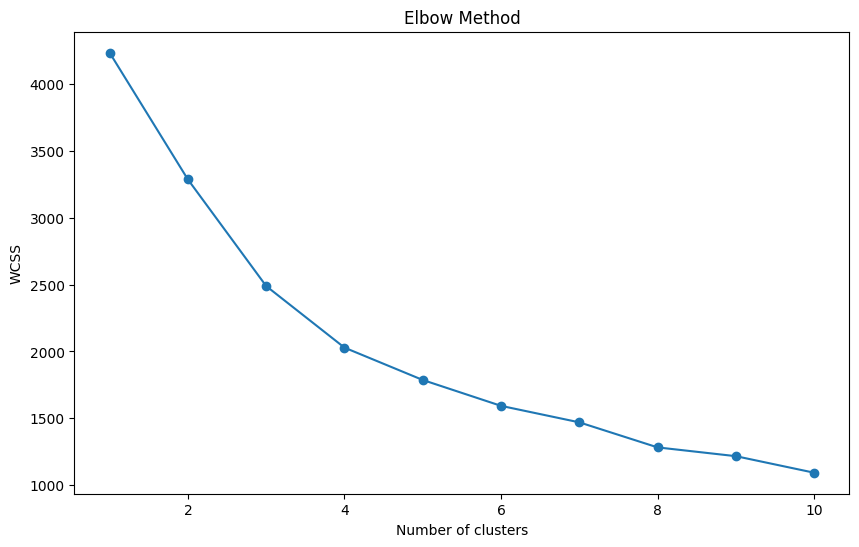

In [31]:
# Plot the Elbow method
plt.figure(figsize=(10,6))
plt.plot(range(1, max_cluster+1), ss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#### Elbow Method Insight

- The WCSS decreases sharply when the number of clusters increases from **1 to 4**, indicating improved clustering performance.
- After **k = 4**, the decrease in WCSS becomes more gradual, meaning additional clusters provide limited improvement.

**Conclusion:**  
The optimal number of clusters is approximately **4**, as this point represents the "elbow" where adding more clusters yields diminishing returns.

**Train K-Means with k = 4**

In [32]:
# Initialize the K-Means model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model to the PCA-transformed dataset and predict cluster labels
clusters = kmeans.fit_predict(pca_df)

# Add the cluster labels to the PCA dataframe
pca_df['cluster'] = clusters

# Also append the cluster labels to the original churned dataset
churned_data['cluster'] = clusters

**Cluster Visualization (PCA)**

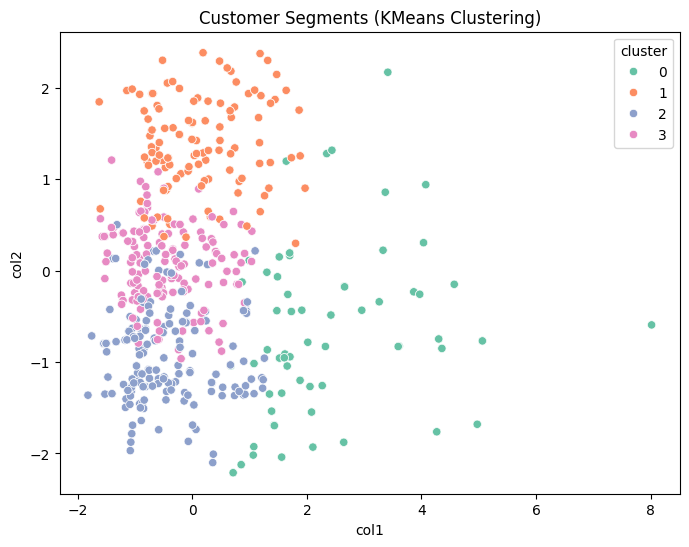

In [33]:
# Create a figure for the scatter plot
plt.figure(figsize=(8,6))

# Plot PCA components with cluster labels
sns.scatterplot(
    data=pca_df,
    x='col1',        # First principal component (PC1)
    y='col2',        # Second principal component (PC2)
    hue='cluster',   # Color points by cluster label
    palette='Set2'   # Color palette for different clusters
)

# Add a title to the visualization
plt.title('Customer Segments (KMeans Clustering)')

# Display the plot
plt.show()


#### Customer Segmentation Insight (K-Means Clustering)

- The visualization shows **four distinct customer clusters**, indicating that customers can be grouped based on similar behavioral patterns.
- **Cluster 0 (green)** spreads further on the right side of the PCA space, suggesting customers with **distinct characteristics compared to other groups**.
- **Cluster 1 (orange)** is concentrated near the center, representing a **large group of customers with average behavior**.
- **Cluster 2 (blue)** appears in the lower-left area, indicating a **segment with similar but slightly different patterns from the central group**.
- **Cluster 3 (pink)** forms a group in the upper region, suggesting **another unique customer segment with different behavior patterns**.

**Cluster Size Distribution**

In [34]:
# Count the number of data points in each cluster
pca_df['cluster'].value_counts()

,count
cluster,
2,307
3,302
1,220
0,119


**Customer Cluster Profiling**

In [35]:
# Calculate the average values of each feature for every cluster
cluster_profile = churned_data.groupby('cluster').mean()

# Display the cluster profile
cluster_profile

,Tenure,CashbackAmount,WarehouseToHome,Complain,DaySinceLastOrder
cluster,,,,,
0,13.680672,218.145630,15.621849,0.403361,6.537815
1,2.522727,164.279091,28.854545,0.718182,3.500000
2,2.097720,150.194300,13.687296,0.000000,2.315961
3,2.754967,145.103510,11.824503,1.000000,2.635762


**Cluster Centroids Visualization**

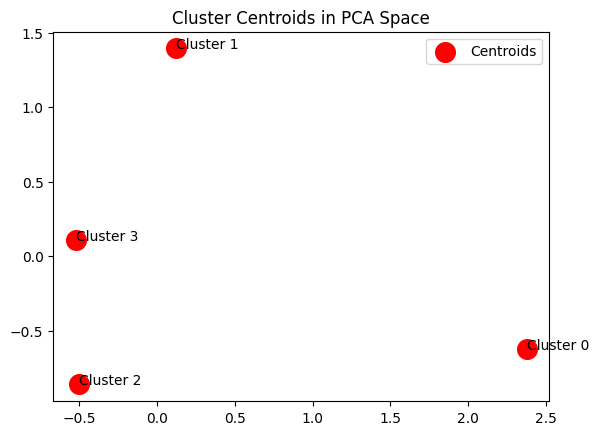

In [36]:
# Extract the centroid coordinates of each cluster
centroids = kmeans.cluster_centers_

# Plot the centroids on the PCA scatter plot
plt.scatter(centroids[:,0], centroids[:,1],
            s=200, c='red', label='Centroids')

# Add label for each centroid
for i in range(len(centroids)):
    plt.text(centroids[i,0], centroids[i,1], f'Cluster {i}')

# Add chart title
plt.title('Cluster Centroids in PCA Space')

# Show legend
plt.legend()

# Display plot
plt.show()

**Churned Customer Segmentation Visualization**

**Chart: Cluster Feature Comparison**

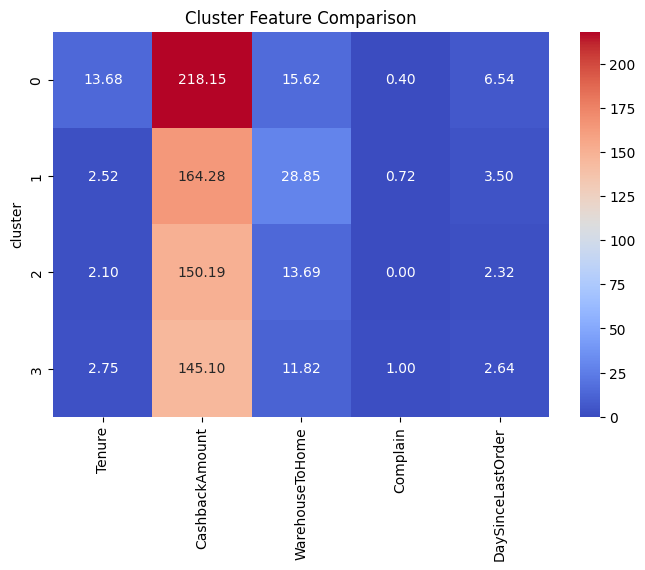

In [37]:
# Create a heatmap to visualize and compare feature values across clusters
plt.figure(figsize=(8,5))
sns.heatmap(cluster_profile, annot=True, cmap='coolwarm', fmt='.2f')

# Add title to describe the chart
plt.title('Cluster Feature Comparison')

# Display the heatmap
plt.show()

#### Insight

The heatmap highlights clear behavioral differences across clusters.  
Cluster 0 shows the **highest tenure and cashback amount**, along with the **longest time since last order**.  
Cluster 1 has the **highest complaint rate**, indicating potential service dissatisfaction.  
Cluster 2 exhibits **low values across most features**, suggesting lower engagement.  
Cluster 3 has the **largest warehouse-to-home distance** and relatively **high cashback**.

**Distribution of Key Features by Cluster**

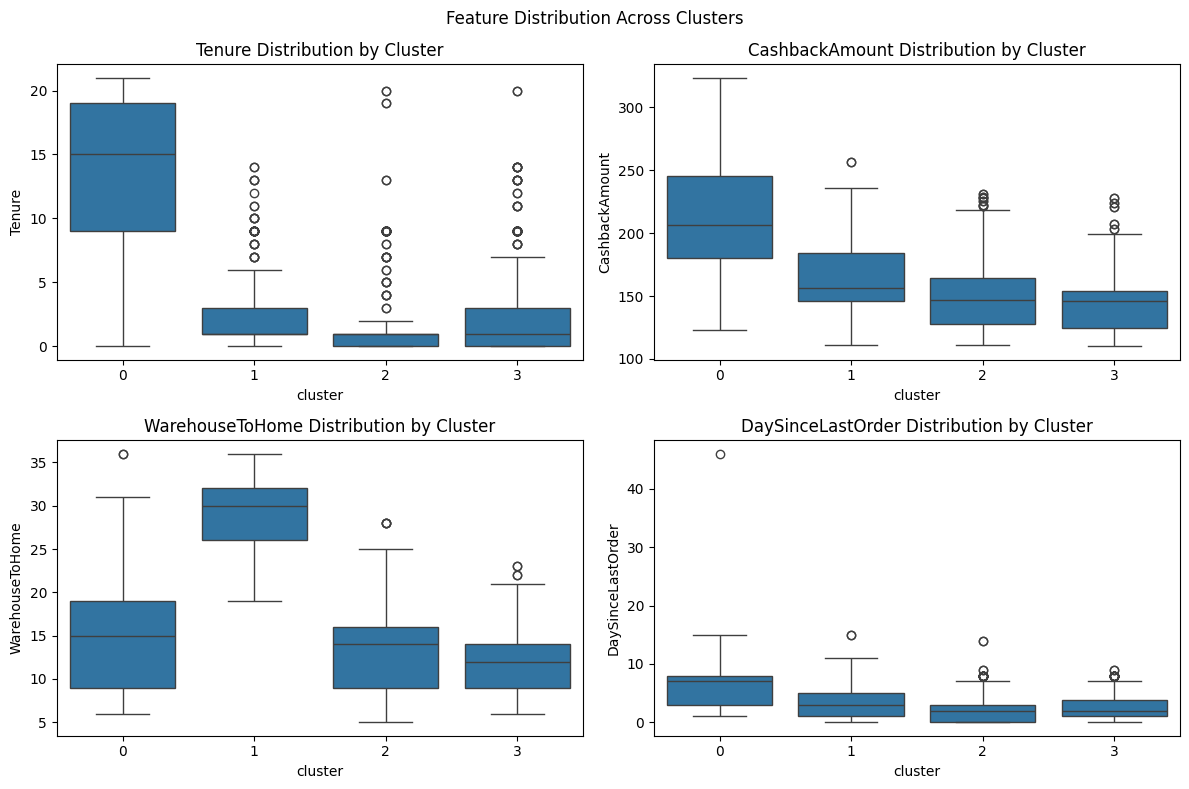

In [38]:
# Create boxplots to visualize feature distributions across clusters
features = ['Tenure','CashbackAmount','WarehouseToHome','DaySinceLastOrder']

# Create a 2x2 layout for the charts
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(features):

    # Plot boxplot for each feature by cluster
    sns.boxplot(
        x='cluster',
        y=col,
        data=churned_data,
        ax=axes[i]
    )

    # Add title for each subplot
    axes[i].set_title(f'{col} Distribution by Cluster')

# Add overall title for the figure
fig.suptitle('Feature Distribution Across Clusters')

# Adjust layout for better spacing
plt.tight_layout()

# Display the charts
plt.show()

**Cluster Size Visualization**

/tmp/ipykernel_191/1359365050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


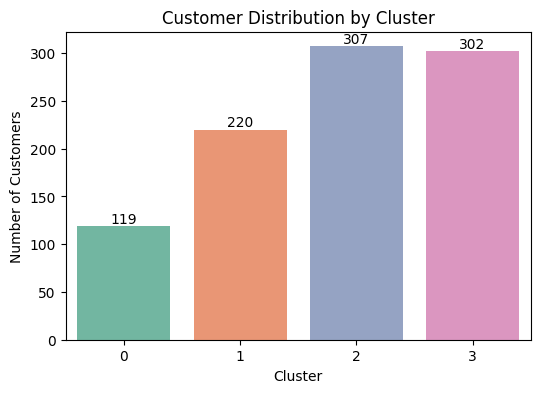

In [39]:
# Create a figure with specified size
plt.figure(figsize=(6,4))

# Generate a countplot to show the number of customers in each cluster
ax = sns.countplot(
    x='cluster',
    data=churned_data,
    palette='Set2'
)

# Loop through each bar in the chart
for p in ax.patches:

    # Add a text label showing the count value on top of each bar
    ax.annotate(
        f'{int(p.get_height())}',                 # Text: number of customers
        (p.get_x() + p.get_width() / 2,           # X position: center of the bar
         p.get_height()),                         # Y position: top of the bar
        ha='center',                              # Horizontally center the text
        va='bottom'                               # Place text slightly above the bar
    )

# Add title to describe the chart
plt.title('Customer Distribution by Cluster')

# Add axis labels
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

# Display the chart
plt.show()

### Insights & Business Recommendations

- **Low tenure customers churn more easily**  
  → Customers with short tenure appear frequently in high-risk churn clusters.  
  **Recommendation:** Improve onboarding experience and provide early engagement incentives.

- **Customer complaints strongly relate to churn**  
  → Customers who submitted complaints show a significantly higher churn rate.  
  **Recommendation:** Improve complaint handling and implement faster customer support resolution.

- **Inactive customers have high churn risk**  
  → Customers with longer *DaysSinceLastOrder* are more likely to churn.  
  **Recommendation:** Launch re-engagement campaigns such as reminders, promotions, or personalized offers.

- **Delivery distance impacts customer experience**  
  → Customers with larger *WarehouseToHome* distance show higher dissatisfaction.  
  **Recommendation:** Optimize logistics and improve delivery coverage or time estimates.

- **Rewards improve customer retention**  
  → Higher *CashbackAmount* is associated with stronger customer engagement.  
  **Recommendation:** Strengthen loyalty programs and offer targeted cashback incentives.

- **Customer segments behave differently**  
  → Clustering reveals four distinct customer groups with different behaviors.  
  **Recommendation:** Apply cluster-based marketing and personalized retention strategies.